In [18]:
from sklearn.datasets import fetch_openml 
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X = mnist["data"]
y = mnist["target"]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (70000, 784)
y shape: (70000,)


الصور الأصلية قيم البكسلات فيها من ٠ الى ٢٥٥ قسمت على ٢٥٥ عشان تصير بين ٠ و١ لان الديكودر في اخر طبقه فيه sigmoid 

وهو يطلع قيم بين الصفر والواحد ف لازم المدخلات تكون بنفس هذا الرينج عشان اللوس ينحسب صح وبعد عشان القيم الصغيره تخلي  التدريب يكون اسرع

In [3]:
X = X.astype(np.float32) / 255.0
y = y.astype(np.int32)
print("X dtype:", X.dtype)
print("y dtype:", y.dtype)
print("Min pixel value:", X.min())
print("Max pixel value:", X.max())

X dtype: float32
y dtype: int32
Min pixel value: 0.0
Max pixel value: 1.0


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=10000, random_state=42
)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (60000, 784)
y_train shape: (60000,)
X_test shape: (10000, 784)
y_test shape: (10000,)


In [5]:
inputSize = 784
hiddenSize = 256
bottleneckSize = 32

In [7]:
encoder = keras.models.Sequential(
    [
        keras.layers.Input(shape=(inputSize,)),
        keras.layers.Dense(hiddenSize, activation="relu"),
        keras.layers.Dense(bottleneckSize, activation="relu"),
    ],name="encoder"
)
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         8,224 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,184 (817.12 KB)

 Trainable params: 209,184 (817.12 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
decoder = keras.models.Sequential( 
    [
        keras.layers.Input(shape=(bottleneckSize,)),
        keras.layers.Dense(hiddenSize, activation="relu"),
        keras.layers.Dense(inputSize, activation="sigmoid"),
    ],name="decoder"
)
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │         8,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,936 (820.06 KB)

 Trainable params: 209,936 (820.06 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
autoencoder = keras.models.Sequential([encoder, decoder], name="autoencoder")
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Sequential)            │ (None, 32)             │       209,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 784)            │       209,936 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 419,120 (1.60 MB)

 Trainable params: 419,120 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")
history = autoencoder.fit(X_train, X_train, epochs=20, batch_size=256, validation_split=0.2)

Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3237 - val_loss: 0.1429
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1330 - val_loss: 0.1130
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1092 - val_loss: 0.1021
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1004 - val_loss: 0.0978
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0966 - val_loss: 0.0948
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0943 - val_loss: 0.0932
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0925 - val_loss: 0.0920
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0912 - val_loss: 0.0907
Epoch 9/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0901 - val_loss: 0.0901
Epoch 10/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0893 - val_loss: 0.0889
Epoch 11/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0885 - val_loss: 0.0881
Epoch 12/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 807us/step


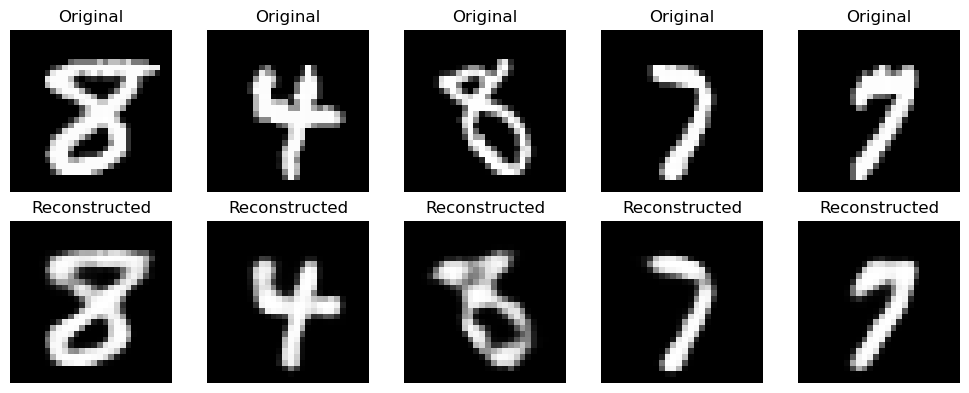

In [11]:
test = autoencoder.predict(X_test)
n = 5
plt.figure(figsize=(10, 4))
for i in range(n):
    # Original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(test[i].reshape(28, 28), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")
plt.tight_layout()
plt.show()

الهدف منه إثبات إن ال Encoder تعلم صح


لان ضغطنا حجم المدخل من ٧٨٤ الى ٣٢ ابي اجاوب على هل ال ٣٢ رقم فعلا فيها معلومات مفيدة؟


باختصار: هذا الرسم هو يثبت إن ال latent space منظم وجاهز نستخدمه

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 357us/step


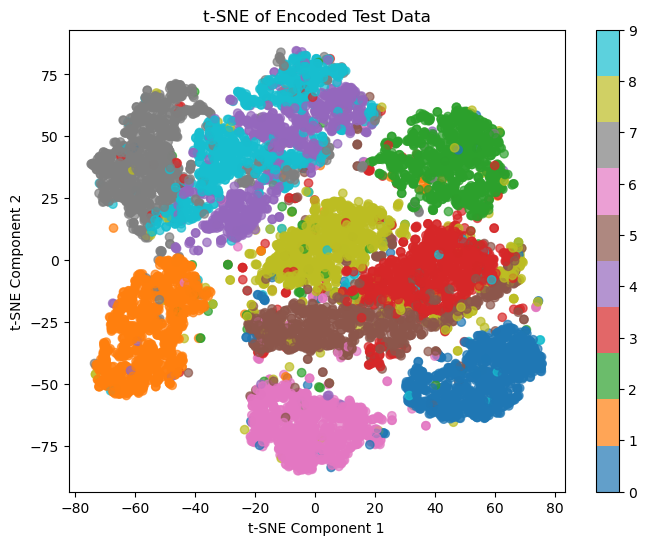

In [14]:
encoderTest = encoder.predict(X_test)
tsne = TSNE(n_components=2, random_state=42)
X_embedded = tsne.fit_transform(encoderTest)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y_test, cmap="tab10", alpha=0.7)
plt.colorbar(scatter, ticks=range(10))
plt.title("t-SNE of Encoded Test Data")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()

In [15]:
X_train_encoded = encoder.predict(X_train)
X_test_encoded = encoder.predict(X_test)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 373us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 423us/step


In [16]:
print ("Encoded training data shape:", X_train_encoded.shape)
print("Encoded test data shape:", X_test_encoded.shape)

Encoded training data shape: (60000, 32)
Encoded test data shape: (10000, 32)


In [43]:
query_image_index = 340
query_image = X_test[query_image_index].reshape(1, -1)
encoded_query = encoder.predict(query_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


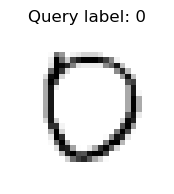

In [44]:
plt.figure(figsize=(2, 2))
plt.imshow(query_image.reshape(28, 28), cmap="binary")
plt.title(f"Query label: {y_test[query_image_index]}")
plt.axis("off")
plt.show()

In [45]:
similarityScores = cosine_similarity(encoded_query, X_train_encoded)

In [ ]:
simImg = 5
most_similar_indices = np.argsort(similarityScores[0])[::-1][:simImg]
most_similar_indices

array([43103, 49959,  8893, 21939, 29039])

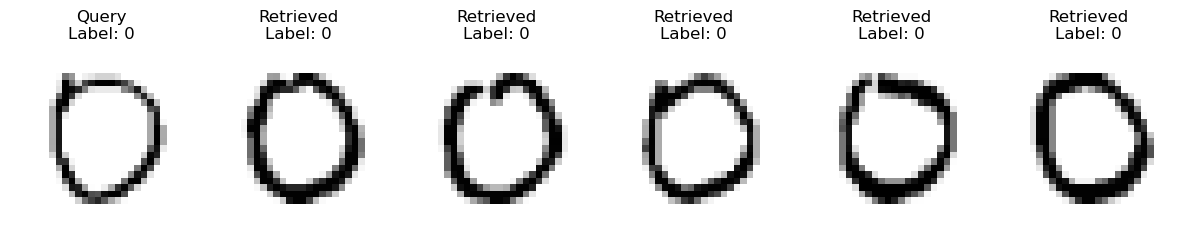

In [ ]:
plt.figure(figsize=(12, 3))

plt.subplot(1, simImg + 1, 1)
plt.imshow(query_image.reshape(28, 28), cmap="binary")
plt.title(f"Query\nLabel: {y_test[query_image_index]}")
plt.axis("off")
for i, idx in enumerate(most_similar_indices):
    plt.subplot(1, simImg + 1, i + 2)
    plt.imshow(X_train[idx].reshape(28, 28), cmap="binary")
    plt.title(f"Retrieved\nLabel: {y_train[idx]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## Summary 
- Loaded the MNIST dataset (70,000 images of handwritten digits, each 28x28 = 784 pixels)
- Normalized pixel values to 0-1 range and split data into 60,000 train and 10,000 test
- Built an autoencoder with an encoder (784 → 256 → 32) and a decoder (32 → 256 → 784)
- Trained the model using binary crossentropy loss and Adam optimizer for 20 epochs
- Visualized original vs reconstructed images to verify the model learned correctly
- Used t-SNE to reduce encoded representations to 2D and plotted them, showing clear clusters for each digit
- Built a retrieval system that encodes a query image, compares it to all training images using cosine similarity, and returns the top 5 most similar images